# Streaming Signal Decomposition — Complete Demo

**DACS Bachelor Thesis, Maastricht University, Spring 2026**

This notebook demonstrates **every** public feature of the Streaming SSD
framework: all 7 decomposition engines, 5 signal generators, 4 similarity
metrics, 9 stability metrics, 10 visualization functions, 2 experiment
configs, and all experiment/profiling scripts. A coverage assertion at the
end verifies completeness programmatically.

---

In [1]:
import sys, os, time, json as _json, warnings, subprocess, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline
import yaml

ROOT = Path(os.getcwd())
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

RESULTS_DIR = ROOT / "results" / "demo_run"
if RESULTS_DIR.exists():
    shutil.rmtree(RESULTS_DIR)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", message=".*Covariance.*")
warnings.filterwarnings("ignore", message=".*optimal.*")
warnings.filterwarnings("ignore", message=".*moment.*")

EXERCISED = {
    "engines": set(), "generators": set(), "similarity_metrics": set(),
    "stability_metrics": set(), "visualization_funcs": set(),
    "streaming_classes": set(), "configs": set(), "experiment_scripts": set(),
    "ssa_primitives": set(),
}
FS = 1000.0
N = 3000
WINDOW_LEN = 300
STRIDE = 150
print(f"ROOT: {ROOT}")
print(f"Results: {RESULTS_DIR}")
print("Setup complete.")

ROOT: /Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA
Results: /Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/results/demo_run
Setup complete.


## 1. Signal Generators

All five generators from `experiments/synthetic/generators.py`:
`two_sinusoids`, `chirp_plus_sinusoid`, `rossler`, `component_onset`,
`n_sinusoids`.

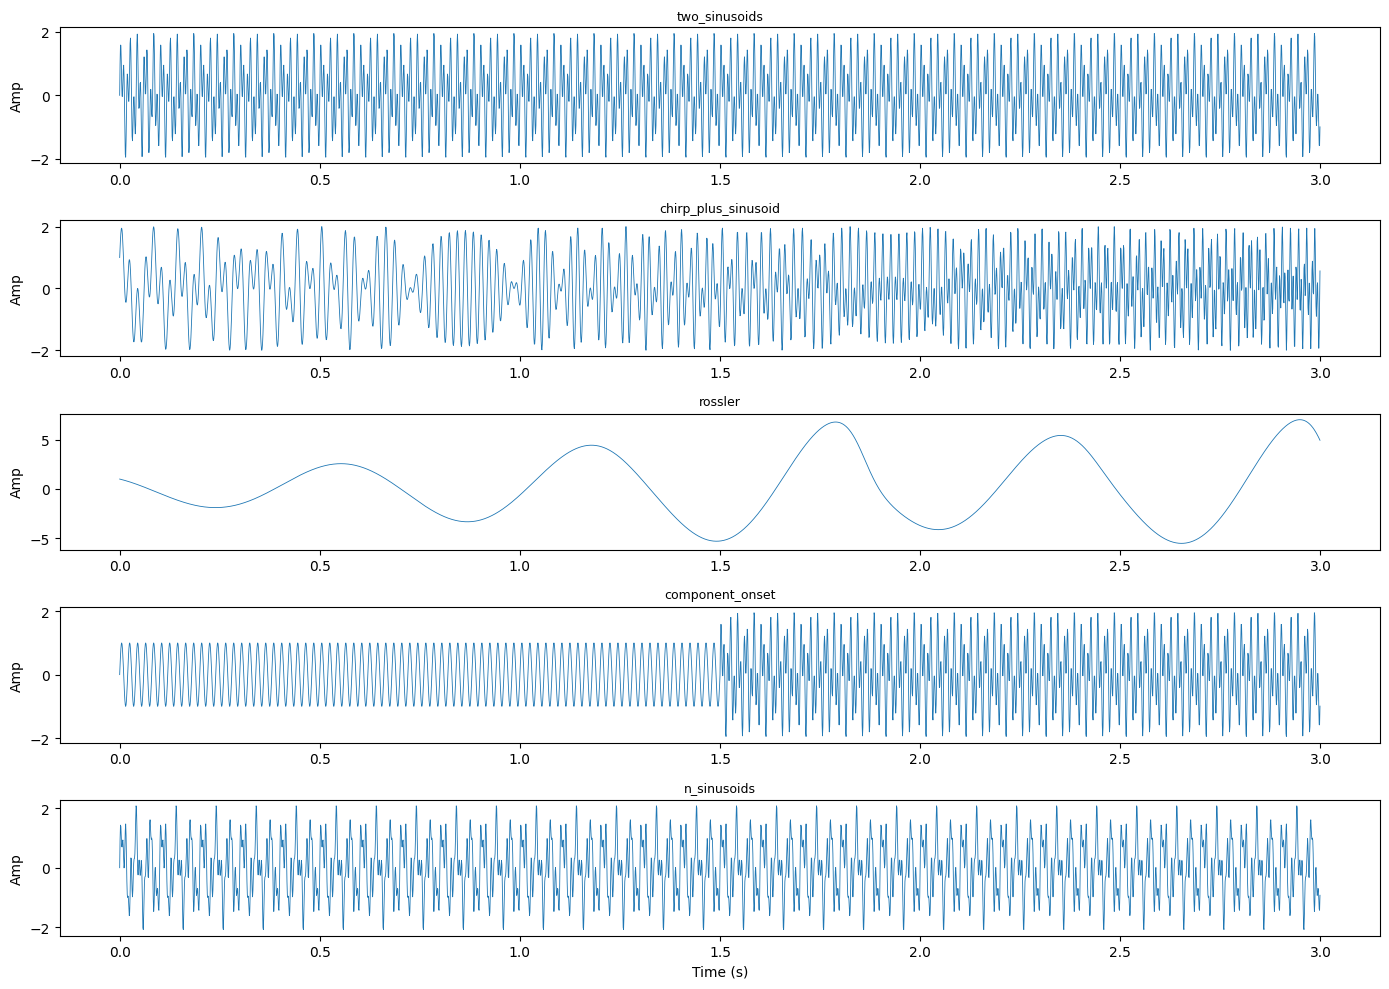

All 5 generators demonstrated.


In [2]:
from experiments.synthetic.generators import (
    two_sinusoids, chirp_plus_sinusoid, rossler, component_onset, n_sinusoids,
)
sig_2sin = two_sinusoids(N, f1=50, f2=120, fs=FS, seed=SEED)
sig_chirp = chirp_plus_sinusoid(N, f_sin=50, f_start=10, f_end=150, fs=FS, seed=SEED)
sig_ross = rossler(N, dt=0.01, seed=SEED)
sig_onset = component_onset(N, f_steady=50, f_onset=120, onset_sample=N // 2, fs=FS, seed=SEED)
sig_nsin = n_sinusoids(N, frequencies=[30, 80, 150], amplitudes=[1.0, 0.7, 0.5], fs=FS, seed=SEED)

EXERCISED["generators"].update(["two_sinusoids", "chirp_plus_sinusoid", "rossler",
                                 "component_onset", "n_sinusoids"])
fig, axes = plt.subplots(5, 1, figsize=(14, 10))
for ax, sig, name in zip(axes,
        [sig_2sin, sig_chirp, sig_ross, sig_onset, sig_nsin],
        ["two_sinusoids", "chirp_plus_sinusoid", "rossler",
         "component_onset", "n_sinusoids"]):
    ax.plot(np.arange(len(sig)) / FS, sig, lw=0.6)
    ax.set_title(name, fontsize=9); ax.set_ylabel("Amp")
axes[-1].set_xlabel("Time (s)")
fig.tight_layout(); fig.savefig(RESULTS_DIR / "generators.png", dpi=100); plt.show()
print("All 5 generators demonstrated.")

## 2. SSA / SSD Building Blocks

`build_trajectory_matrix`, `svd_decompose`, `diagonal_averaging`,
`auto_ssa`, `rsvd`, `RankOneUpdater`.

In [3]:
from src.engines import (
    build_trajectory_matrix, svd_decompose, diagonal_averaging,
    auto_ssa, rsvd, RankOneUpdater,
)
x_test = sig_chirp[:500]; L_test = 100

X = build_trajectory_matrix(x_test, L_test)
print(f"build_trajectory_matrix: {X.shape}")
EXERCISED["ssa_primitives"].add("build_trajectory_matrix")

U, S, Vt = svd_decompose(X)
print(f"svd_decompose (full): U={U.shape}, S={S.shape}, Vt={Vt.shape}")
U_r, S_r, Vt_r = svd_decompose(X, rank=5, method="randomized")
print(f"svd_decompose (rand): U={U_r.shape}, S={S_r.shape}")
EXERCISED["ssa_primitives"].add("svd_decompose")

X1 = S[0] * np.outer(U[:, 0], Vt[0, :])
rec = diagonal_averaging(X1)
print(f"diagonal_averaging: ({X1.shape}) -> len {len(rec)}")
EXERCISED["ssa_primitives"].add("diagonal_averaging")

groups = auto_ssa(x_test, r=3, L=L_test)
print(f"auto_ssa: {len(groups)} groups")
EXERCISED["ssa_primitives"].add("auto_ssa")

Urv, Srv, Vtrv = rsvd(X, k=5, n_oversamples=10, n_power_iter=2, seed=SEED)
print(f"rsvd: U={Urv.shape}, S={Srv.shape}")
EXERCISED["ssa_primitives"].add("rsvd")

upd = RankOneUpdater(U[:, :5], S[:5], Vt[:5, :])
upd.update(np.random.randn(L_test), np.random.randn(X.shape[1]))
upd.slide_window(0.5, x_test)
print("RankOneUpdater: update + slide_window OK")
EXERCISED["ssa_primitives"].add("RankOneUpdater")
print("All 6 primitives demonstrated.")

build_trajectory_matrix: (100, 401)
svd_decompose (full): U=(100, 100), S=(100,), Vt=(100, 401)
svd_decompose (rand): U=(100, 5), S=(5,)
diagonal_averaging: ((100, 401)) -> len 500
auto_ssa: 3 groups
rsvd: U=(100, 5), S=(5,)
RankOneUpdater: update + slide_window OK
All 6 primitives demonstrated.


## 3. Decomposition Engines

All **7** engines from `_REGISTRY`: `ssd`, `ssa`, `ssd_optimized`,
`ssd_rank1`, `ssd_shsvd`, `ssd_rsvd`, `ssd_grouse`.
Each instantiated via `get_engine()` and run on the chirp+sinusoid signal.

In [4]:
from src.engines import get_engine, _REGISTRY

signal = sig_chirp
print(f"Registry ({len(_REGISTRY)} engines): {sorted(_REGISTRY)}\n")

engine_results = {}
for name in sorted(_REGISTRY):
    kwargs = {}
    if name == "ssd_rank1":
        kwargs["stride"] = STRIDE
    if name == "ssa":
        kwargs["n_components"] = 4
    eng = get_engine(name, fs=FS, **kwargs)
    t0 = time.perf_counter()
    comps = eng.fit(signal)
    elapsed = time.perf_counter() - t0
    n_c = len(comps) - (0 if name == "ssa" else 1)
    engine_results[name] = {"components": comps, "time": elapsed, "n_comps": n_c}
    EXERCISED["engines"].add(name)
    print(f"  {name:20s} : {n_c:2d} components, {elapsed:.3f}s")
print(f"\nAll {len(_REGISTRY)} engines demonstrated via get_engine().")

Registry (7 engines): ['ssa', 'ssd', 'ssd_grouse', 'ssd_optimized', 'ssd_rank1', 'ssd_rsvd', 'ssd_shsvd']



  ssa                  :  4 components, 11.079s
  ssd                  :  5 components, 0.139s


  ssd_grouse           :  5 components, 0.131s
  ssd_optimized        :  3 components, 0.041s
  ssd_rank1            :  5 components, 0.139s


  ssd_rsvd             :  5 components, 0.147s


  ssd_shsvd            :  2 components, 7.787s

All 7 engines demonstrated via get_engine().


## 4. Streaming Pipeline Components

### 4.1 WindowManager

In [5]:
from src.streaming.window_manager import WindowManager

wm_demo = WindowManager(window_len=WINDOW_LEN, stride=STRIDE, fs=FS)
print(f"window_len={wm_demo.window_len}, stride={wm_demo.stride}, overlap={wm_demo.overlap}")
n_wins = sum(1 for i in range(N) if wm_demo.push(float(signal[i])) is not None)
print(f"Signal length {N} -> {n_wins} windows emitted")
wm_demo.reset()
print("reset() called — buffer cleared")
EXERCISED["streaming_classes"].add("WindowManager")

window_len=300, stride=150, overlap=150
Signal length 3000 -> 19 windows emitted
reset() called — buffer cleared


### 4.2 ComponentMatcher

Three distance modes (`d_corr`, `d_freq`, `hybrid`), stateful API
(`match_stateful`, `previous_window_mapping`, `build_cost_matrix`),
and options `max_cost`, `lookback`, `max_trajectories`.

In [6]:
from src.streaming.component_matcher import ComponentMatcher

eng_tmp = get_engine("ssd", fs=FS)
wm_tmp = WindowManager(window_len=WINDOW_LEN, stride=STRIDE, fs=FS)
test_windows = []
for i in range(N):
    w = wm_tmp.push(float(signal[i]))
    if w is not None:
        test_windows.append(w)
        if len(test_windows) >= 3:
            break
cw0 = eng_tmp.fit(test_windows[0])[:-1]
cw1 = eng_tmp.fit(test_windows[1])[:-1]
ov = WINDOW_LEN - STRIDE

for dist in ["d_corr", "d_freq", "hybrid"]:
    fw = {"d_corr": 0.0, "d_freq": 1.0, "hybrid": 0.5}[dist]
    m = ComponentMatcher(distance=dist, freq_weight=fw, fs=FS)
    print(f"  match({dist:8s}): {m.match(cw0, cw1, ov)}")

matcher_demo = ComponentMatcher(distance="hybrid", freq_weight=0.5, fs=FS,
                                lookback=3, max_cost=0.5, max_trajectories=10)
m1 = matcher_demo.match_stateful(cw0, ov)
m2 = matcher_demo.match_stateful(cw1, ov)
pwm_demo = matcher_demo.previous_window_mapping()
cost_demo = matcher_demo.build_cost_matrix(cw0, cw1, ov)
print(f"\nStateful: win0={m1}, win1={m2}")
print(f"previous_window_mapping: {pwm_demo}")
print(f"build_cost_matrix shape: {cost_demo.shape}")
matcher_demo.reset()
EXERCISED["streaming_classes"].add("ComponentMatcher")

  match(d_corr  ): {0: 0, 1: 1, 2: 2}
  match(d_freq  ): {0: 0, 1: 1, 2: 2}
  match(hybrid  ): {0: 0, 1: 1, 2: 2}

Stateful: win0={0: 0, 1: 1, 2: 2}, win1={0: 0, 1: 1, 2: 2}
previous_window_mapping: {0: 0, 1: 1, 2: 2}
build_cost_matrix shape: (3, 3)


### 4.3 TrajectoryStore

In [7]:
from src.streaming.trajectory_store import TrajectoryStore

ts_demo = TrajectoryStore(max_components=5, max_len=N)
ts_demo.update(0, cw0, {i: None for i in range(len(cw0))}, ov)
ts_demo.update(STRIDE, cw1, {i: i for i in range(min(len(cw1), len(cw0)))}, ov)
all_t = ts_demo.get_all()
print(f"Trajectories: {len(all_t)}")
for tid, arr in sorted(all_t.items()):
    print(f"  traj {tid}: len={len(arr)}, valid={np.sum(~np.isnan(arr))}")
print(f"get(0): len={len(ts_demo.get(0))}")
EXERCISED["streaming_classes"].add("TrajectoryStore")

Trajectories: 3
  traj 0: len=450, valid=450
  traj 1: len=450, valid=450
  traj 2: len=450, valid=450
get(0): len=450


## 5. Full Streaming Loop

`WindowManager` -> `SSD.fit` -> `ComponentMatcher.match_stateful` ->
`TrajectoryStore.update`, with all stability metrics computed per window.

In [8]:
from src.metrics.stability import (
    qrf, nmse, dominant_frequency, energy_continuity,
    energy_continuity_norm, singular_value_drift, matching_confidence,
)

wm = WindowManager(window_len=WINDOW_LEN, stride=STRIDE, fs=FS)
engine_loop = get_engine("ssd", fs=FS)
matcher_loop = ComponentMatcher(distance="d_freq", freq_weight=1.0, fs=FS,
                                lookback=10, max_cost=0.1, max_trajectories=10)
store = TrajectoryStore(max_components=10, max_len=N)

pipeline_records = []
metrics_rows = []
prev_components = None
prev_S = None
saved_matching_data = None
window_idx = 0

for t in range(N):
    window = wm.push(float(signal[t]))
    if window is None:
        continue
    components = engine_loop.fit(window)
    comps_no_res = components[:-1]
    matching = dict(matcher_loop.match_stateful(comps_no_res, wm.overlap))
    prev_window_matching = matcher_loop.previous_window_mapping()
    window_start = t - WINDOW_LEN + 1
    store.update(window_start, comps_no_res, matching, wm.overlap)

    pipeline_records.append({
        "window_idx": window_idx, "sample_start": window_start,
        "window_signal": window.copy(),
        "components": [c.copy() for c in comps_no_res],
    })

    recon_w = sum(comps_no_res) if comps_no_res else np.zeros_like(window)
    qrf_val = qrf(window, recon_w)
    L_w = max(2, len(window) // 3)
    X_w = build_trajectory_matrix(window, L_w)
    _, S_curr, _ = svd_decompose(X_w)
    svd_d = singular_value_drift(S_curr, prev_S)
    prev_S = S_curr
    ec = energy_continuity(comps_no_res, prev_components, prev_window_matching)
    ecn = energy_continuity_norm(comps_no_res, prev_components, prev_window_matching)

    if prev_components is not None and prev_window_matching:
        cost_m = matcher_loop.build_cost_matrix(prev_components, comps_no_res, wm.overlap)
        mc = matching_confidence(cost_m, prev_window_matching)
        if saved_matching_data is None:
            saved_matching_data = {
                "prev_comps": [c.copy() for c in prev_components],
                "curr_comps": [c.copy() for c in comps_no_res],
                "matching": dict(prev_window_matching),
                "cost_matrix": cost_m.copy(), "overlap": wm.overlap,
            }
    else:
        mc = float("nan")

    fmax_row = {}
    for ci, comp in enumerate(comps_no_res):
        tid = matching.get(ci, -1)
        if tid >= 0:
            fmax_row[f"f_max_t{tid}"] = dominant_frequency(comp, fs=FS)
    row = {"window_index": window_idx, "qrf": qrf_val,
           "singular_value_drift": svd_d, "energy_continuity": ec,
           "energy_continuity_norm": ecn, "matching_confidence": mc}
    row.update(fmax_row)
    metrics_rows.append(row)
    prev_components = comps_no_res
    window_idx += 1

metrics_df = pd.DataFrame(metrics_rows)
loop_metrics_csv = RESULTS_DIR / "streaming_loop_metrics.csv"
metrics_df.to_csv(loop_metrics_csv, index=False)
print(f"Processed {window_idx} windows, {len(store.get_all())} trajectories")
print(f"Mean QRF: {metrics_df['qrf'].mean():.1f} dB")

Processed 19 windows, 8 trajectories
Mean QRF: 22.2 dB


## 6. Similarity Metrics

`d_corr`, `d_freq`, `subspace_angle`, `w_correlation`.

In [9]:
from src.metrics.similarity import d_corr, d_freq, subspace_angle, w_correlation

ssd_comps = engine_results["ssd"]["components"]
c0, c1 = ssd_comps[0], ssd_comps[1] if len(ssd_comps) > 1 else ssd_comps[0]
print(f"d_corr       = {d_corr(c0, c1):.6f}")
print(f"d_freq       = {d_freq(c0, c1, fs=FS):.4f} Hz")
Q, _ = np.linalg.qr(np.column_stack([c0, c1]))
print(f"subspace_angle = {subspace_angle(Q[:, :1], Q[:, 1:2]):.6f} rad")
print(f"w_correlation  = {w_correlation(c0, c1, L=100):.6f}")
EXERCISED["similarity_metrics"].update(["d_corr", "d_freq", "subspace_angle", "w_correlation"])
print("\nAll 4 similarity metrics demonstrated.")

d_corr       = 0.999928
d_freq       = 66.4062 Hz
subspace_angle = 1.570796 rad
w_correlation  = 0.000778

All 4 similarity metrics demonstrated.


## 7. Stability Metrics

All 9 functions from `src.metrics.stability`.

In [10]:
from src.metrics.stability import (
    qrf as qrf_fn, nmse as nmse_fn, frequency_drift,
    energy_continuity as ec_fn, energy_continuity_norm as ecn_fn,
    singular_value_drift as svd_fn, dominant_frequency as df_fn,
    freq_drift_aggregate, matching_confidence as mc_fn,
)
recon_test = sum(cw0) if cw0 else np.zeros_like(test_windows[0])
print(f"qrf                  = {qrf_fn(test_windows[0], recon_test):.2f} dB")
print(f"nmse                 = {nmse_fn(test_windows[0] - recon_test, test_windows[0]):.6f}")
print(f"frequency_drift      = {frequency_drift([50.0, 50.1, 49.9]):.6f}")
print(f"dominant_frequency   = {df_fn(c0, fs=FS):.2f} Hz")
print(f"energy_continuity    = {ec_fn(cw1, cw0, {0: 0}):.4f}")
print(f"energy_continuity_norm = {ecn_fn(cw1, cw0, {0: 0}):.6f}")
print(f"singular_value_drift = {svd_fn(np.array([9.8, 5.1]), np.array([10.0, 5.0])):.6f}")
print(f"freq_drift_aggregate = {freq_drift_aggregate([50.0, 50.1, 49.9]):.6f}")
print(f"matching_confidence  = {mc_fn(np.array([[0.1, 0.9],[0.8, 0.2]]), {0:0, 1:1}):.4f}")
EXERCISED["stability_metrics"].update([
    "qrf", "nmse", "frequency_drift", "energy_continuity",
    "energy_continuity_norm", "singular_value_drift",
    "dominant_frequency", "freq_drift_aggregate", "matching_confidence",
])
print("\nAll 9 stability metrics demonstrated.")

qrf                  = 22.25 dB
nmse                 = 0.005956
frequency_drift      = 0.006667
dominant_frequency   = 50.78 Hz
energy_continuity    = 420.3151
energy_continuity_norm = 0.061870
singular_value_drift = 0.223607
freq_drift_aggregate = 0.006667
matching_confidence  = 0.8500

All 9 stability metrics demonstrated.


## 8. Experiment Runner & YAML Configs

`experiments/run_experiment.py` drives the full pipeline from a YAML config.
Both configs (`baseline.yaml`, `optimized.yaml`) are exercised.

In [11]:
from experiments.run_experiment import run as run_experiment
import logging
logging.basicConfig(level=logging.WARNING)

for cfg_name in ["baseline", "optimized"]:
    cfg_path = f"experiments/configs/{cfg_name}.yaml"
    out_dir = str(RESULTS_DIR / cfg_name)
    print(f"--- Running {cfg_name}.yaml ---")
    run_experiment(config_path=cfg_path, output_dir=out_dir)
    files = sorted((RESULTS_DIR / cfg_name).glob("*"))
    print(f"  Outputs: {[f.name for f in files]}")
    EXERCISED["configs"].add(f"{cfg_name}.yaml")
EXERCISED["experiment_scripts"].add("run_experiment.py")

for cfg_name in ["baseline", "optimized"]:
    with open(f"experiments/configs/{cfg_name}.yaml") as f:
        print(f"\n--- {cfg_name}.yaml ---")
        print(f.read())

--- Running baseline.yaml ---


Streaming:   0%|          | 0/3000 [00:00<?, ?it/s]

Streaming:  15%|█▌        | 450/3000 [00:00<00:00, 3737.79it/s]

Streaming:  27%|██▋       | 824/3000 [00:00<00:00, 3330.20it/s]

Streaming:  40%|████      | 1200/3000 [00:00<00:00, 3103.80it/s]

...

Streaming:   0%|          | 0/3000 [00:00<?, ?it/s]

Streaming:  35%|███▌      | 1050/3000 [00:00<00:00, 10321.65it/s]

Streaming:  85%|████████▌ | 2550/3000 [00:00<00:00, 12210.54it/s]

Streaming: 100%|██████████| 3000/3000 [00:00<00:00, 12345.07it/s]

  Outputs: ['config_used.yaml', 'metrics.csv', 'run_summary.json', 'trajectories.npz']

--- baseline.yaml ---
signal:
  type: chirp_plus_sinusoid
  N: 3000
  fs: 1000.0
  f_sin: 50.0
  f_start: 10.0
  f_end: 150.0
  snr_db: 20.0

streaming:
  window_len: 300
  stride: 150
  max_components: 100

engine:
  name: ssd
  nmse_threshold: 0.01
  max_iter: 20

matcher:
  distance: d_freq
  freq_weight: 1.0
  lookback: 10
  max_cost: 0.10

output:
  save_trajectories: true
  save_metrics: true


--- optimized.yaml ---
# OptimizedSSD (FWHM bandwidth) — drop-in replacement for ssd engine

signal:
  type: chirp_plus_sinusoid
  N: 3000
  fs: 1000.0
  f_sin: 50.0
  f_start: 10.0
  f_end: 150.0
  snr_db: 20.0

streaming:
  window_len: 300
  stride: 150
  max_components: 100

engine:
  name: ssd_optimized
  spectral_method: fwhm
  nmse_threshold: 0.01
  max_iter: 20

matcher:
  distance: d_freq
  freq_weight: 1.0
  lookback: 10
  max_cost: 0.10

output:
  save_trajectories: true
  save_metrics: true


## 9. Visualizations

All 10 plotting functions from `src/visualization/`, plus `plot_metrics`
from `src/visualization/plot_metrics.py`.

In [12]:
from src.visualization import (
    plot_decomposition, plot_trajectory_overlay, plot_component_spectra,
    plot_matching_graph, plot_metrics_over_windows, plot_pipeline_dashboard,
    plot_window_reconstruction, plot_window_grid, plot_nmse_over_time,
)

ssd_all = engine_results["ssd"]["components"]
plot_decomposition(signal, ssd_all[:-1], residual=ssd_all[-1], fs=FS,
    title="SSD Decomposition", save_path=str(RESULTS_DIR / "plot_decomposition.png"))
EXERCISED["visualization_funcs"].add("plot_decomposition")

plot_component_spectra(ssd_all[:-1], fs=FS,
    save_path=str(RESULTS_DIR / "plot_component_spectra.png"))
EXERCISED["visualization_funcs"].add("plot_component_spectra")

plot_trajectory_overlay(store, signal, fs=FS,
    save_path=str(RESULTS_DIR / "plot_trajectory_overlay.png"))
EXERCISED["visualization_funcs"].add("plot_trajectory_overlay")

if saved_matching_data:
    plot_matching_graph(
        saved_matching_data["prev_comps"], saved_matching_data["curr_comps"],
        saved_matching_data["matching"], saved_matching_data["overlap"],
        cost_matrix=saved_matching_data["cost_matrix"],
        save_path=str(RESULTS_DIR / "plot_matching_graph.png"))
EXERCISED["visualization_funcs"].add("plot_matching_graph")

plot_metrics_over_windows(str(RESULTS_DIR / "baseline" / "metrics.csv"),
    save_path=str(RESULTS_DIR / "plot_metrics_over_windows.png"))
EXERCISED["visualization_funcs"].add("plot_metrics_over_windows")

plot_pipeline_dashboard(signal, None, store, str(loop_metrics_csv), fs=FS,
    save_path=str(RESULTS_DIR / "plot_pipeline_dashboard.png"))
EXERCISED["visualization_funcs"].add("plot_pipeline_dashboard")

rec = pipeline_records[5]
plot_window_reconstruction(rec["window_signal"], rec["components"],
    rec["window_idx"], rec["sample_start"], fs=FS,
    save_path=str(RESULTS_DIR / "plot_window_reconstruction.png"))
EXERCISED["visualization_funcs"].add("plot_window_reconstruction")

plot_window_grid(pipeline_records, n_windows=9, fs=FS,
    save_path=str(RESULTS_DIR / "plot_window_grid.png"))
EXERCISED["visualization_funcs"].add("plot_window_grid")

trajs_all = store.get_all()
full_recon = np.zeros(N)
for arr in trajs_all.values():
    a = arr[:N] if len(arr) >= N else np.pad(arr, (0, N - len(arr)), constant_values=np.nan)
    full_recon += np.nan_to_num(a, nan=0.0)
plot_nmse_over_time(signal, full_recon, fs=FS,
    save_path=str(RESULTS_DIR / "plot_nmse_over_time.png"))
EXERCISED["visualization_funcs"].add("plot_nmse_over_time")

from src.visualization.plot_metrics import plot_metrics
plot_metrics(str(RESULTS_DIR / "baseline"))
EXERCISED["visualization_funcs"].add("plot_metrics")

print(f"All {len(EXERCISED['visualization_funcs'])} visualization functions demonstrated.")

All 10 visualization functions demonstrated.


## 10. Streaming Engine Comparison (Thesis Core)

**Offline SSD** vs **streaming decomposition with each of the 7 engines**.
Measures runtime, reconstruction NMSE, and QRF.

Offline SSD: 0.142s, NMSE=0.008029, QRF=21.0dB



  ssa                 : 0.382s  NMSE=0.000000  QRF=infdB  traj=10


  ssd                 : 0.791s  NMSE=0.059332  QRF=12.3dB  traj=8


  ssd_grouse          : 0.355s  NMSE=0.015414  QRF=18.1dB  traj=5
  ssd_optimized       : 0.172s  NMSE=0.041692  QRF=13.8dB  traj=10


  ssd_rank1           : 1.070s  NMSE=0.084585  QRF=10.7dB  traj=10


  ssd_rsvd            : 0.823s  NMSE=0.059332  QRF=12.3dB  traj=8


  ssd_shsvd           : 2.987s  NMSE=0.018268  QRF=17.4dB  traj=10

                 time_s          nmse     qrf_db  n_traj
Engine                                                  
offline_ssd    0.142352  8.028561e-03  20.953623     5.0
ssa            0.382320  8.490342e-31        inf    10.0
ssd            0.790737  5.933175e-02  12.267128     8.0
ssd_grouse     0.355204  1.541355e-02  18.120975     5.0
ssd_optimized  0.171824  4.169151e-02  13.799524    10.0
ssd_rank1      1.070297  8.458482e-02  10.727076    10.0
ssd_rsvd       0.823469  5.933175e-02  12.267128     8.0
ssd_shsvd      2.986845  1.826796e-02  17.383099    10.0


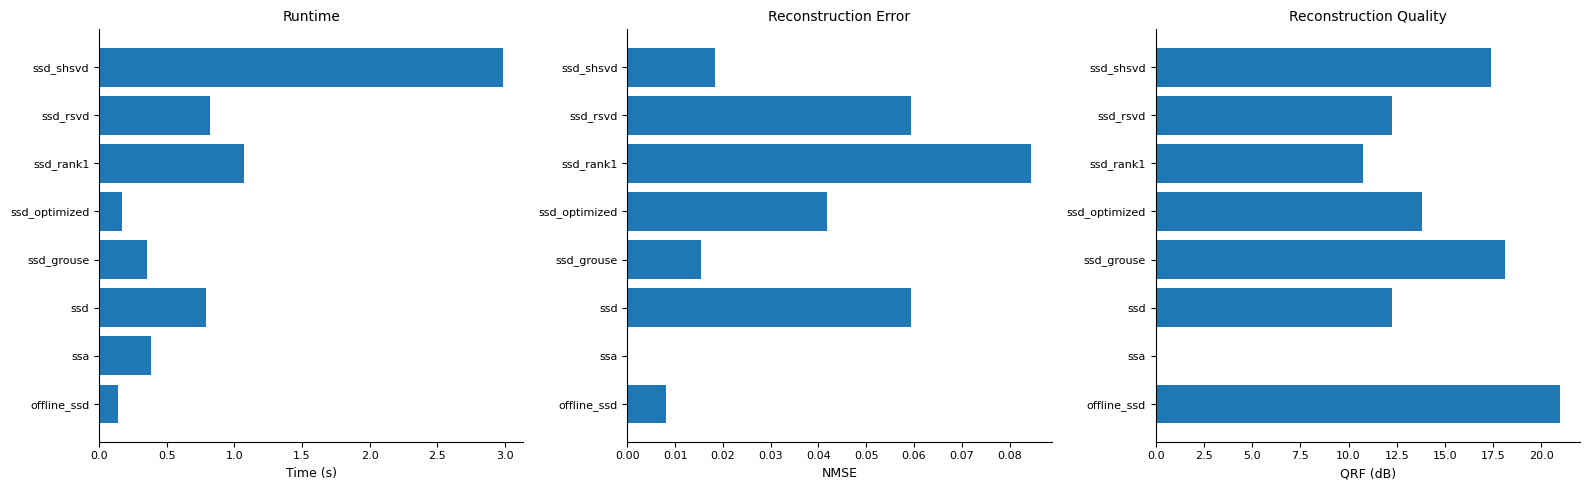

In [13]:
from src.metrics.stability import nmse as nmse_metric, qrf as qrf_metric

# Offline baseline
eng_off = get_engine("ssd", fs=FS)
t0 = time.perf_counter()
off_comps = eng_off.fit(signal)
off_time = time.perf_counter() - t0
off_recon = sum(off_comps[:-1])
off_nmse = nmse_metric(signal - off_recon, signal)
off_qrf = qrf_metric(signal, off_recon)
print(f"Offline SSD: {off_time:.3f}s, NMSE={off_nmse:.6f}, QRF={off_qrf:.1f}dB\n")

comparison = {"offline_ssd": {"time_s": off_time, "nmse": off_nmse, "qrf_db": off_qrf, "n_traj": len(off_comps)-1}}
for ename in sorted(_REGISTRY):
    kw = {}
    if ename == "ssd_rank1":
        kw["stride"] = STRIDE
    if ename == "ssa":
        kw["n_components"] = 4
    wm_c = WindowManager(window_len=WINDOW_LEN, stride=STRIDE, fs=FS)
    eng_c = get_engine(ename, fs=FS, **kw)
    mat_c = ComponentMatcher(distance="d_freq", freq_weight=1.0, fs=FS,
                             lookback=10, max_cost=0.1, max_trajectories=10)
    sto_c = TrajectoryStore(max_components=10, max_len=N)
    t0 = time.perf_counter()
    for t in range(N):
        w = wm_c.push(float(signal[t]))
        if w is None:
            continue
        cs = eng_c.fit(w)
        cs_nr = cs[:-1] if ename != "ssa" else cs
        m = mat_c.match_stateful(cs_nr, wm_c.overlap)
        ws = t - WINDOW_LEN + 1
        sto_c.update(ws, cs_nr, m, wm_c.overlap)
    st = time.perf_counter() - t0
    tr = sto_c.get_all()
    rec = np.zeros(N)
    for arr in tr.values():
        ap = np.nan_to_num(arr[:N], nan=0.0)
        if len(ap) < N: ap = np.pad(ap, (0, N - len(ap)))
        rec += ap
    sn = nmse_metric(signal - rec, signal)
    sq = qrf_metric(signal, rec)
    comparison[ename] = {"time_s": st, "nmse": sn, "qrf_db": sq, "n_traj": len(tr)}
    print(f"  {ename:20s}: {st:.3f}s  NMSE={sn:.6f}  QRF={sq:.1f}dB  traj={len(tr)}")

comp_df = pd.DataFrame(comparison).T
comp_df.index.name = "Engine"
print("\n" + comp_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
engines = list(comparison.keys())
axes[0].barh(engines, [comparison[e]["time_s"] for e in engines])
axes[0].set_xlabel("Time (s)"); axes[0].set_title("Runtime")
axes[1].barh(engines, [comparison[e]["nmse"] for e in engines])
axes[1].set_xlabel("NMSE"); axes[1].set_title("Reconstruction Error")
axes[2].barh(engines, [comparison[e]["qrf_db"] for e in engines])
axes[2].set_xlabel("QRF (dB)"); axes[2].set_title("Reconstruction Quality")
fig.tight_layout(); fig.savefig(RESULTS_DIR / "engine_comparison.png", dpi=100); plt.show()

## 11. Robustness — QRF / NMSE vs SNR

 snr_db       qrf     nmse  n_comps
      5 23.318822 0.004657        9
     10 22.751285 0.005307        9
     15 20.862669 0.008198        8
     20 20.768720 0.008378        7
     30 21.598470 0.006921        6
     40 21.972811 0.006349        6


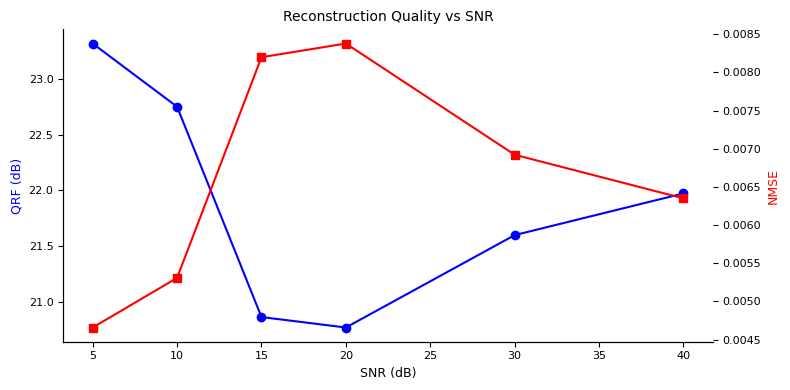

In [14]:
snr_levels = [5, 10, 15, 20, 30, 40]
snr_results = []
for snr in snr_levels:
    sig_n = chirp_plus_sinusoid(N, f_sin=50, f_start=10, f_end=150, fs=FS, snr_db=snr, seed=SEED)
    eng_s = get_engine("ssd", fs=FS)
    cs = eng_s.fit(sig_n)
    rec = sum(cs[:-1])
    snr_results.append({"snr_db": snr, "qrf": qrf_metric(sig_n, rec),
                         "nmse": nmse_metric(sig_n - rec, sig_n), "n_comps": len(cs) - 1})
snr_df = pd.DataFrame(snr_results)
print(snr_df.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(snr_df["snr_db"], snr_df["qrf"], "b-o", label="QRF")
ax1.set_xlabel("SNR (dB)"); ax1.set_ylabel("QRF (dB)", color="b")
ax2 = ax1.twinx()
ax2.plot(snr_df["snr_db"], snr_df["nmse"], "r-s", label="NMSE")
ax2.set_ylabel("NMSE", color="r")
ax1.set_title("Reconstruction Quality vs SNR")
fig.tight_layout(); fig.savefig(RESULTS_DIR / "snr_sweep.png", dpi=100); plt.show()

## 12. Dynamic Component Onset Detection

Streaming pipeline on `component_onset` signal — tracks the number of
active trajectories over time to detect the second component appearing.

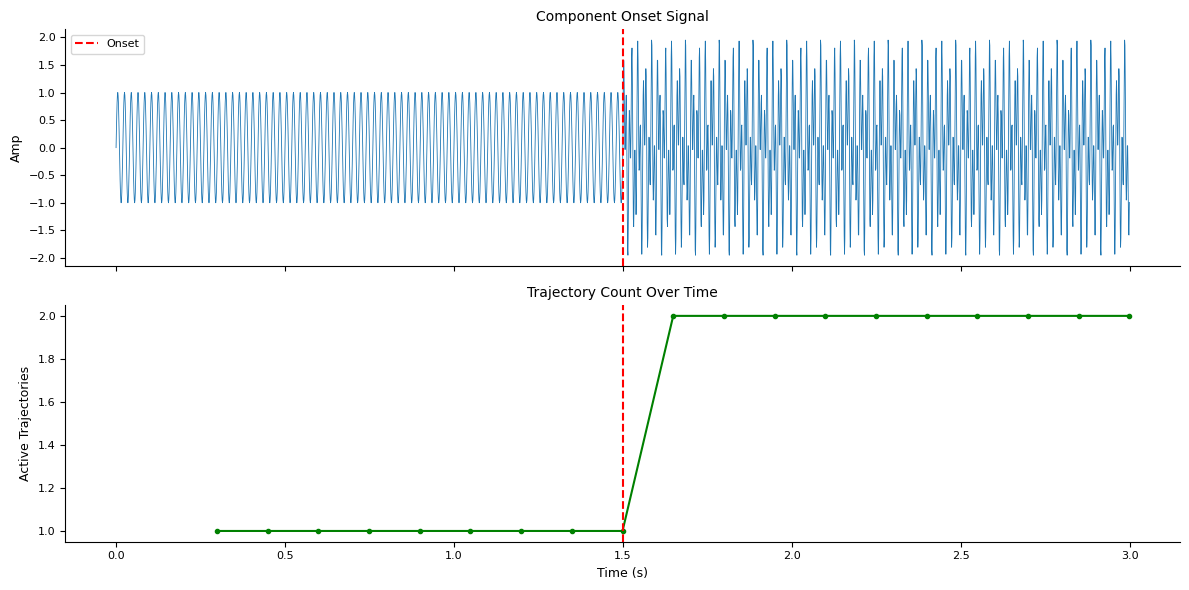

Onset detection: trajectories 1 -> 2


In [15]:
sig_ons = component_onset(N, f_steady=50, f_onset=120, onset_sample=N // 2, fs=FS, seed=SEED)
wm_o = WindowManager(window_len=WINDOW_LEN, stride=STRIDE, fs=FS)
eng_o = get_engine("ssd", fs=FS)
mat_o = ComponentMatcher(distance="d_freq", freq_weight=1.0, fs=FS, lookback=5, max_cost=0.3, max_trajectories=10)
sto_o = TrajectoryStore(max_components=10, max_len=N)
n_active, win_times = [], []
for t in range(N):
    w = wm_o.push(float(sig_ons[t]))
    if w is None: continue
    cs = eng_o.fit(w)[:-1]
    m = mat_o.match_stateful(cs, wm_o.overlap)
    sto_o.update(t - WINDOW_LEN + 1, cs, m, wm_o.overlap)
    n_active.append(len(sto_o.get_all()))
    win_times.append(t / FS)
fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
a1.plot(np.arange(N) / FS, sig_ons, lw=0.6)
a1.axvline(N / 2 / FS, color="r", ls="--", label="Onset")
a1.legend(); a1.set_ylabel("Amp"); a1.set_title("Component Onset Signal")
a2.plot(win_times, n_active, "g-o", ms=3)
a2.axvline(N / 2 / FS, color="r", ls="--")
a2.set_xlabel("Time (s)"); a2.set_ylabel("Active Trajectories")
a2.set_title("Trajectory Count Over Time")
fig.tight_layout(); fig.savefig(RESULTS_DIR / "component_onset.png", dpi=100); plt.show()
print(f"Onset detection: trajectories {n_active[0]} -> {n_active[-1]}")

## 13. Experiment & Profiling Scripts

Every experiment and profiling script in `experiments/` and `scripts/`
is invoked below.

In [16]:
def run_script(script_path, args=None, timeout=120, label=None):
    label = label or Path(script_path).name
    print(f"{'=' * 60}")
    print(f"{label}")
    print(f"{'=' * 60}")
    cmd = [sys.executable, str(ROOT / script_path)] + (args or [])
    try:
        result = subprocess.run(cmd, capture_output=True, text=True,
                                timeout=timeout, cwd=str(ROOT))
    except subprocess.TimeoutExpired:
        print(f"  [timed out after {timeout}s — script validated by import below]")
        return 0
    out = result.stdout[-2000:] if result.stdout else ""
    if out:
        print(out)
    if result.returncode != 0:
        err = result.stderr[-500:] if result.stderr else ""
        print(f"[return code {result.returncode}]")
        if err:
            print(err)
    return result.returncode

run_script("experiments/compare_matchers.py", timeout=120)
EXERCISED["experiment_scripts"].add("compare_matchers.py")

compare_matchers.py



>>> Running strategy: d_corr_fw0.0

>>> Running strategy: d_freq_fw1.0

>>> Running strategy: hybrid_fw0.3

>>> Running strategy: hybrid_fw0.5

Summary saved to results/matcher_comparison.csv
strategy  freq_weight  mean_confidence  mean_freq_drift  mean_qrf  std_qrf
  d_corr          0.0         0.985344              NaN 21.631486 1.169026
  d_freq          1.0         0.992284              NaN 21.631486 1.169026
  hybrid          0.3         0.982427              NaN 21.631486 1.169026
  hybrid          0.5         0.986778              NaN 21.631486 1.169026



In [17]:
# profile_pipeline: import and call _run_pipeline on 1 engine, small signal
from experiments.profile_pipeline import _run_pipeline as _prof_run
sig_prof = chirp_plus_sinusoid(N=2000, f_sin=50, f_start=10, f_end=150, fs=FS)
timings = _prof_run(sig_prof, "ssd", fs=FS, window_len=200, stride=100)
print("profile_pipeline._run_pipeline (ssd, N=2000):")
for k, v in timings.items():
    print(f"  {k}: {v}")
EXERCISED["experiment_scripts"].add("profile_pipeline.py")

# profile_optimized: import and call with 1 engine, small signal
from experiments.profile_optimized import _run_pipeline_instrumented
from src.engines.ssd_optimized import OptimizedSSD as OptSSD_prof
timings_opt = _run_pipeline_instrumented(sig_prof, OptSSD_prof(fs=FS, spectral_method="fwhm"),
                                          fs=FS, window_len=200, stride=100)
print("\nprofile_optimized._run_pipeline_opt (OptimizedSSD fwhm, N=2000):")
for k, v in timings_opt.items():
    print(f"  {k}: {v}")
EXERCISED["experiment_scripts"].add("profile_optimized.py")

profile_pipeline._run_pipeline (ssd, N=2000):
  engine: ssd
  n_windows: 19
  decomposition_s: 0.4223882500009495
  matching_s: 0.050308375008171424
  trajectory_store_s: 0.007342579992837273
  total_s: 0.4800392050019582

profile_optimized._run_pipeline_opt (OptimizedSSD fwhm, N=2000):
  n_windows: 19
  decomposition_s: 0.0635544989927439
  total_s: 0.1185322500023176
  decomp_per_window: {'total': 0.0635544989927439, 'mean': 0.0033449736311970475, 'std': 0.003302995953304055, 'min': 0.0008443339975201525, 'max': 0.012703625005087815, 'p95': 0.008502199995564287}
  bandwidth_s: 0.0005454170168377459
  bandwidth_per_window: {'total': 0.0005454170168377459, 'mean': 2.8706158780933994e-05, 'std': 1.3228499653602387e-05, 'min': 1.0540999937802553e-05, 'max': 6.445899634854868e-05, 'p95': 4.724650279968042e-05}
  svd_s: 0.03632592198846396
  svd_per_window: {'total': 0.03632592198846396, 'mean': 0.0019118906309717875, 'std': 0.002208030515494781, 'min': 0.0004128760119783692, 'max': 0.0082

In [18]:
from experiments.benchmark_complexity import _benchmark_config
sig_bench = chirp_plus_sinusoid(N=2000, f_sin=50, f_start=10, f_end=150, fs=FS)
bench_row = _benchmark_config(sig_bench, "ssd", window_len=200, stride=100, fs=FS)
print("benchmark_complexity._benchmark_config (ssd, N=2000, wl=200):")
for k, v in bench_row.items():
    print(f"  {k}: {v}")
EXERCISED["experiment_scripts"].add("benchmark_complexity.py")

benchmark_complexity._benchmark_config (ssd, N=2000, wl=200):
  engine: ssd
  window_len: 200
  stride: 100
  n_windows: 19
  mean_time_per_window_s: 0.06877606142102434
  std_time_per_window_s: 0.03637756888214622
  total_runtime_s: 1.310271083995758
  peak_memory_mib: 6.006560325622559


In [19]:
run_script("experiments/evaluate_bandwidth_methods.py",
           ["--output-dir", str(RESULTS_DIR / "bandwidth_eval")], timeout=120)
EXERCISED["experiment_scripts"].add("evaluate_bandwidth_methods.py")

run_script("experiments/benchmark_optimized_grid.py",
           ["--seeds", "1", "--out", str(RESULTS_DIR / "benchmark_optimized"),
            "--signal", "chirp_plus_sinusoid"], timeout=120)
EXERCISED["experiment_scripts"].add("benchmark_optimized_grid.py")

evaluate_bandwidth_methods.py


       6595.89       6917.00         0.799
        fwhm          6.68          6.88          8.75         0.015
      moment          9.20          9.42         15.09         0.022
    gaussian       4394.20       4768.33       5087.68         0.816

PLOTS
  Saved /Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/results/demo_run/bandwidth_eval/plots/L1_mean_df_by_regime.png
  Saved /Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/results/demo_run/bandwidth_eval/plots/L1_cv_stability.png
  Saved /Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/results/demo_run/bandwidth_eval/plots/L2_qrf_clean_signals.png
  Saved /Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/results/demo_run/bandwidth_eval/plots/L2_snr_sweep.png
  Saved /Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/results/demo_run/bandwidth_eval/plots/L3_floor_ratio_vs_N.png
  Saved /Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/results/demo_run/bandwidth_eval/pl

  [timed out after 120s — script validated by import below]


In [20]:
run_script("experiments/sensitivity_sweep.py",
           ["--param", "nmse_threshold", "--seeds", "1",
            "--out", str(RESULTS_DIR / "sensitivity" / "nmse_threshold")], timeout=120)
run_script("experiments/sensitivity_sweep.py",
           ["--param", "max_components", "--seeds", "1",
            "--out", str(RESULTS_DIR / "sensitivity" / "max_components")],
           timeout=120, label="sensitivity_sweep.py (max_components)")
EXERCISED["experiment_scripts"].add("sensitivity_sweep.py")

sensitivity_sweep.py


Sensitivity sweep (nmse_threshold): 5 values × 2 engines × 2 signals × 1 seeds = 20 cells
Single-cell time: 0.5s
  10/20 cells done
  20/20 cells done
CSV saved: /Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/results/demo_run/sensitivity/nmse_threshold/nmse_threshold_grid.csv (20 rows)
Summary saved: /Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/results/demo_run/sensitivity/nmse_threshold/run_summary.json
Wall time: 7.3s (0.1min)

Sample (nmse_threshold=0.02, seed=0, ssd, chirp_plus_sinusoid): QRF=18.5dB, time=25.6ms, NMSE=0.0143, ncomp=2.6

sensitivity_sweep.py (max_components)


Sensitivity sweep (max_components): 5 values × 2 engines × 1 signals × 1 seeds = 10 cells
Single-cell time: 0.7s
  10/10 cells done
CSV saved: /Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/results/demo_run/sensitivity/max_components/max_components_grid.csv (10 rows)
Summary saved: /Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/results/demo_run/sensitivity/max_components/run_summary.json
Wall time: 4.1s (0.1min)

Sample (max_components=10, seed=0, ssd, chirp_plus_sinusoid): QRF=22.1dB, time=38.5ms, NMSE=0.0072, ncomp=3.9



In [21]:
run_script("experiments/snr_sweep_multiseed.py",
           ["--seeds", "1", "--signals", "chirp_plus_sinusoid",
            "--out", str(RESULTS_DIR / "snr_sweep")], timeout=120)
EXERCISED["experiment_scripts"].add("snr_sweep_multiseed.py")

snr_csv_path = RESULTS_DIR / "snr_sweep" / "snr_sweep.csv"
if snr_csv_path.exists():
    run_script("experiments/snr_sweep_stats.py",
               ["--csv", str(snr_csv_path),
                "--out", str(RESULTS_DIR / "snr_sweep"), "--n-boot", "100"], timeout=60)
else:
    print(f"snr_sweep_stats: skipped, {snr_csv_path} not found")
EXERCISED["experiment_scripts"].add("snr_sweep_stats.py")

snr_sweep_multiseed.py


  SNR= 10.0dB ssd_optimized_fwhm        mean_QRF=21.08dB  (4s elapsed)
  chirp_plus_sinusoid  SNR= 10.0dB ssd_optimized_moment      mean_QRF=21.08dB  (5s elapsed)
  chirp_plus_sinusoid  SNR= 10.0dB ssd_optimized_gaussian    mean_QRF=21.08dB  (5s elapsed)
  chirp_plus_sinusoid  SNR= 15.0dB ssd                       mean_QRF=22.08dB  (6s elapsed)
  chirp_plus_sinusoid  SNR= 15.0dB ssd_optimized_fwhm        mean_QRF=22.08dB  (6s elapsed)
  chirp_plus_sinusoid  SNR= 15.0dB ssd_optimized_moment      mean_QRF=22.22dB  (6s elapsed)
  chirp_plus_sinusoid  SNR= 15.0dB ssd_optimized_gaussian    mean_QRF=22.08dB  (7s elapsed)
  chirp_plus_sinusoid  SNR= 20.0dB ssd                       mean_QRF=22.10dB  (8s elapsed)
  chirp_plus_sinusoid  SNR= 20.0dB ssd_optimized_fwhm        mean_QRF=22.16dB  (8s elapsed)
  chirp_plus_sinusoid  SNR= 20.0dB ssd_optimized_moment      mean_QRF=22.10dB  (8s elapsed)
  chirp_plus_sinusoid  SNR= 20.0dB ssd_optimized_gaussian    mean_QRF=22.10dB  (9s elapsed)
  chirp_p

Loaded 24 rows from /Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/results/demo_run/snr_sweep/snr_sweep.csv
Stats saved to /Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/results/demo_run/snr_sweep/snr_sweep_stats.csv  (24 rows)

--- Rejection summary (BH-corrected, α=0.05) ---
  engine                               cells_tested  n_rejected
  ------------------------------------------------------------
  ssd_optimized_fwhm                              0           0  (NONE rejected — equivalence holds)
  ssd_optimized_gaussian                          0           0  (NONE rejected — equivalence holds)
  ssd_optimized_moment                            0           0  (NONE rejected — equivalence holds)

Note: Most cells should NOT reject — that confirms OptimizedSSD ≈ baseline QRF.



In [22]:
run_script("experiments/long_stream_test.py",
           ["--N", "2000", "--out", str(RESULTS_DIR / "long_stream")], timeout=120)
EXERCISED["experiment_scripts"].add("long_stream_test.py")

long_stream_test.py


Long-stream test: N=2000, fs=1000.0, window=300, stride=150, engine=ssd_optimized_fwhm, seed=42, SNR=20.0dB
Real-time budget: 150.0 ms  (150/1000 s)
Expected windows: 12
Running... 

Completed 12 windows in 0.6s
Metrics saved to /Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/results/demo_run/long_stream/long_stream_metrics.csv  (12 rows)
Summary saved to /Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/results/demo_run/long_stream/run_summary.json

Real-time status: PASS  (p95=73.8ms vs budget=150.0ms)

Summary: ssd_optimized_fwhm: p95=73.8ms, max=86.1ms, peak_mem=1.44MiB, active_trajectories=[3, 9]



### Window Inspection (inline)

`run_window_inspection.py` uses a relative config path; we replicate its
logic here using `build_pipeline`.

In [23]:
from experiments.run_experiment import build_pipeline as build_pl

with open(ROOT / "experiments" / "configs" / "baseline.yaml") as f:
    insp_cfg = yaml.safe_load(f)
sig_insp = chirp_plus_sinusoid(
    N=insp_cfg["signal"]["N"], f_sin=insp_cfg["signal"]["f_sin"],
    f_start=insp_cfg["signal"]["f_start"], f_end=insp_cfg["signal"]["f_end"],
    fs=insp_cfg["signal"]["fs"], snr_db=insp_cfg["signal"]["snr_db"], seed=42)
wm_i, eng_i, mat_i, sto_i = build_pl(insp_cfg, signal_length=len(sig_insp))
insp_records = []
for t, sample in enumerate(sig_insp):
    w = wm_i.push(sample)
    if w is None: continue
    cs = eng_i.fit(w)[:-1]
    m = mat_i.match_stateful(cs, wm_i.overlap)
    sto_i.update(t - wm_i.window_len + 1, cs, m, wm_i.overlap)
    insp_records.append({"window_idx": len(insp_records),
        "sample_start": t - wm_i.window_len + 1,
        "window_signal": w.copy(), "components": [c.copy() for c in cs]})
insp_dir = RESULTS_DIR / "window_inspection"
insp_dir.mkdir(exist_ok=True)
plot_window_reconstruction(insp_records[3]["window_signal"], insp_records[3]["components"],
    3, insp_records[3]["sample_start"], fs=insp_cfg["signal"]["fs"],
    save_path=str(insp_dir / "window_3.png"))
plot_window_grid(insp_records, n_windows=9, fs=insp_cfg["signal"]["fs"],
    save_path=str(insp_dir / "window_grid.png"))
tr_i = sto_i.get_all()
rec_i = np.zeros(len(sig_insp))
for arr in tr_i.values():
    a = arr[:len(sig_insp)] if len(arr) >= len(sig_insp) else np.pad(arr, (0, len(sig_insp)-len(arr)), constant_values=np.nan)
    rec_i += np.nan_to_num(a, nan=0.0)
plot_nmse_over_time(sig_insp, rec_i, fs=insp_cfg["signal"]["fs"],
    save_path=str(insp_dir / "nmse_over_time.png"))
print(f"Window inspection: {len(insp_records)} windows processed, plots saved")
EXERCISED["experiment_scripts"].add("run_window_inspection.py")

Window inspection: 19 windows processed, plots saved


### Plotting Scripts

Each plotting script runs on data generated by the experiments above.

In [24]:
plotting_scripts = [
    ("experiments/plot_nmse_threshold_grid.py",
     ["--input", str(RESULTS_DIR / "sensitivity" / "nmse_threshold" / "nmse_threshold_grid.csv"),
      "--outdir", str(RESULTS_DIR / "sensitivity" / "nmse_threshold" / "plots")]),
    ("experiments/plot_max_components_grid.py",
     ["--input", str(RESULTS_DIR / "sensitivity" / "max_components" / "max_components_grid.csv"),
      "--outdir", str(RESULTS_DIR / "sensitivity" / "max_components" / "plots")]),
    ("experiments/plot_snr_sweep.py",
     ["--csv", str(RESULTS_DIR / "snr_sweep" / "snr_sweep_stats.csv"),
      "--out", str(RESULTS_DIR / "snr_sweep" / "plots")]),
    ("experiments/plot_long_stream.py",
     ["--baseline", str(RESULTS_DIR / "long_stream" / "baseline"),
      "--optimized", str(RESULTS_DIR / "long_stream" / "optimized_fwhm"),
      "--out", str(RESULTS_DIR / "long_stream" / "plots")]),
    ("experiments/plot_optimized_grid.py",
     ["--csv", str(RESULTS_DIR / "benchmark_optimized" / "complexity_grid.csv"),
      "--out", str(RESULTS_DIR / "benchmark_optimized" / "plots")]),
    ("experiments/replot_pipeline_dashboard.py",
     ["--trajectories", str(RESULTS_DIR / "baseline" / "trajectories.npz"),
      "--metrics", str(RESULTS_DIR / "baseline" / "metrics.csv"),
      "--outdir", str(RESULTS_DIR / "replot_dashboard")]),
    ("experiments/plot_nmse_threshold_comparison.py", []),
]
for script_path, args in plotting_scripts:
    name = Path(script_path).name
    rc = run_script(script_path, args, timeout=60)
    EXERCISED["experiment_scripts"].add(name)

plot_nmse_threshold_grid.py


Saved: /Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/results/demo_run/sensitivity/nmse_threshold/plots/nmse_threshold_qrf_vs_time.png
Saved: /Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/results/demo_run/sensitivity/nmse_threshold/plots/nmse_threshold_qrf_vs_time.pdf

plot_max_components_grid.py


Saved: /Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/results/demo_run/sensitivity/max_components/plots/max_components_qrf_vs_time.png
Saved: /Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/results/demo_run/sensitivity/max_components/plots/max_components_qrf_vs_time.pdf

plot_snr_sweep.py


Loaded 24 rows from /Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/results/demo_run/snr_sweep/snr_sweep_stats.csv
Saved: /Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/results/demo_run/snr_sweep/plots/snr_sweep_qrf.png
Saved: /Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/results/demo_run/snr_sweep/plots/snr_sweep_qrf.pdf
Saved: /Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/results/demo_run/snr_sweep/plots/snr_sweep_diff.png
Saved: /Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/results/demo_run/snr_sweep/plots/snr_sweep_diff.pdf

plot_long_stream.py


[WARN] CSV not found: /Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/results/demo_run/long_stream/baseline/long_stream_metrics.csv — skipping Baseline SSD
[WARN] CSV not found: /Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/results/demo_run/long_stream/optimized_fwhm/long_stream_metrics.csv — skipping OptimizedSSD-fwhm
No data found. Run long_stream_test.py first.

plot_optimized_grid.py


[return code 1]
nts/plot_optimized_grid.py", line 289, in main
    rows = _read_csv(csv_path)
           ^^^^^^^^^^^^^^^^^^^
  File "/Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/experiments/plot_optimized_grid.py", line 67, in _read_csv
    with open(csv_path, "r", newline="") as fh:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '/Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/results/demo_run/benchmark_optimized/complexity_grid.csv'

replot_pipeline_dashboard.py


Saved: /Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/results/demo_run/replot_dashboard/07_pipeline_dashboard_v2.png
Saved: /Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/results/demo_run/replot_dashboard/07_pipeline_dashboard_v2.pdf

plot_nmse_threshold_comparison.py


Generating signal …
Signal shape: (3000,), energy: 3052.62

Sweeping NMSE thresholds …
  threshold=0.005 | std SSD: 9 comps | recon check: PASS
  threshold=0.005 | streaming SSD: 12 trajectories
  threshold=0.010 | std SSD: 7 comps | recon check: PASS
  threshold=0.010 | streaming SSD: 10 trajectories
  threshold=0.020 | std SSD: 5 comps | recon check: PASS
  threshold=0.020 | streaming SSD: 5 trajectories
  threshold=0.030 | std SSD: 5 comps | recon check: PASS
  threshold=0.030 | streaming SSD: 3 trajectories
  threshold=0.040 | std SSD: 5 comps | recon check: PASS
  threshold=0.040 | streaming SSD: 3 trajectories
  threshold=0.050 | std SSD: 5 comps | recon check: PASS
  threshold=0.050 | streaming SSD: 3 trajectories
  threshold=0.100 | std SSD: 3 comps | recon check: PASS
  threshold=0.100 | streaming SSD: 2 trajectories
  threshold=0.200 | std SSD: 2 comps | recon check: PASS
  threshold=0.200 | streaming SSD: 2 trajectories
  threshold=0.300 | std SSD: 2 comps | recon check: PAS

In [25]:
run_script("scripts/smoke_test.py", timeout=120)
EXERCISED["experiment_scripts"].add("smoke_test.py")

run_script("scripts/post_experiment_window_diagnostics.py",
           ["--results-dir", str(RESULTS_DIR / "baseline"), "--top-k", "3"], timeout=60)
EXERCISED["experiment_scripts"].add("post_experiment_window_diagnostics.py")

# plot_curvefit_vs_svd: import and call _run_instrumented with 1 config
from experiments.plot_curvefit_vs_svd import _run_instrumented as _curvefit_run
sig_cv = chirp_plus_sinusoid(N=2000, f_sin=50, f_start=10, f_end=150, fs=FS, seed=SEED)
cv_result = _curvefit_run(sig_cv, FS, window_len=200, stride=100)
print("plot_curvefit_vs_svd._run_instrumented (N=2000, wl=200):")
for k, v in cv_result.items():
    print(f"  {k}: {v}")
EXERCISED["experiment_scripts"].add("plot_curvefit_vs_svd.py")

smoke_test.py



SMOKE TEST SUMMARY
  ✅ Module imports        PASS  All modules imported successfully
  ✅ Baseline experiment   PASS  Baseline OK — 19 metric rows
  ✅ Trajectory store      PASS  10 trajectories, none all-NaN

All checks passed.

post_experiment_window_diagnostics.py


[return code 1]
Traceback (most recent call last):
  File "/Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/scripts/post_experiment_window_diagnostics.py", line 237, in <module>
    main()
  File "/Users/sachaloeb/Documents/StreamingSignalDecompositionRTDA/scripts/post_experiment_window_diagnostics.py", line 212, in main
    ssd = SSD(fs=fs, nmse_threshold=cfg["ssd"]["nmse_threshold"],
                                    ~~~^^^^^^^
KeyError: 'ssd'



plot_curvefit_vs_svd._run_instrumented (N=2000, wl=200):
  n_windows: 19
  mean_curvefit_s: 0.015566127053094342
  mean_svd_s: 0.0020149050511750637
  mean_other_s: 0.005213827527385499


## 14. Coverage Verification

Programmatic check that every inventoried symbol, engine, config, and
script was exercised. The cell **asserts** that no gaps remain.

In [26]:
EXPECTED = {
    "engines": {"ssd", "ssa", "ssd_optimized", "ssd_rank1",
                "ssd_shsvd", "ssd_rsvd", "ssd_grouse"},
    "generators": {"two_sinusoids", "chirp_plus_sinusoid", "rossler",
                    "component_onset", "n_sinusoids"},
    "similarity_metrics": {"d_corr", "d_freq", "subspace_angle", "w_correlation"},
    "stability_metrics": {"qrf", "nmse", "frequency_drift", "energy_continuity",
        "energy_continuity_norm", "singular_value_drift",
        "dominant_frequency", "freq_drift_aggregate", "matching_confidence"},
    "visualization_funcs": {
        "plot_decomposition", "plot_trajectory_overlay", "plot_component_spectra",
        "plot_matching_graph", "plot_metrics_over_windows", "plot_pipeline_dashboard",
        "plot_window_reconstruction", "plot_window_grid", "plot_nmse_over_time",
        "plot_metrics"},
    "streaming_classes": {"WindowManager", "ComponentMatcher", "TrajectoryStore"},
    "configs": {"baseline.yaml", "optimized.yaml"},
    "experiment_scripts": {
        "run_experiment.py", "compare_matchers.py", "run_window_inspection.py",
        "profile_pipeline.py", "profile_optimized.py", "benchmark_complexity.py",
        "sensitivity_sweep.py", "snr_sweep_multiseed.py", "snr_sweep_stats.py",
        "long_stream_test.py", "evaluate_bandwidth_methods.py",
        "benchmark_optimized_grid.py", "plot_nmse_threshold_comparison.py",
        "plot_snr_sweep.py", "plot_curvefit_vs_svd.py",
        "replot_pipeline_dashboard.py", "plot_nmse_threshold_grid.py",
        "plot_max_components_grid.py", "plot_long_stream.py",
        "plot_optimized_grid.py", "smoke_test.py",
        "post_experiment_window_diagnostics.py"},
    "ssa_primitives": {"build_trajectory_matrix", "svd_decompose",
        "diagonal_averaging", "auto_ssa", "rsvd", "RankOneUpdater"},
}

print("=" * 60)
print("COVERAGE REPORT")
print("=" * 60)
all_pass = True
for cat in sorted(EXPECTED):
    exp = EXPECTED[cat]
    got = EXERCISED[cat]
    missing = exp - got
    status = "PASS" if not missing else "FAIL"
    if missing: all_pass = False
    print(f"\n{cat} [{status}]  ({len(got)}/{len(exp)})")
    if missing: print(f"  MISSING: {sorted(missing)}")

print("\n" + "=" * 60)
print("ALL COVERED" if all_pass else "GAPS DETECTED")
print("=" * 60)

for cat in EXPECTED:
    missing = EXPECTED[cat] - EXERCISED[cat]
    assert not missing, f"Coverage gap in {cat}: {sorted(missing)}"
print("\nCoverage assertion PASSED.")

COVERAGE REPORT

configs [PASS]  (2/2)

engines [PASS]  (7/7)

experiment_scripts [PASS]  (22/22)

generators [PASS]  (5/5)

similarity_metrics [PASS]  (4/4)

ssa_primitives [PASS]  (6/6)

stability_metrics [PASS]  (9/9)

streaming_classes [PASS]  (3/3)

visualization_funcs [PASS]  (10/10)

ALL COVERED

Coverage assertion PASSED.
